<a href="https://colab.research.google.com/github/gustadavi/Analises_UnB/blob/main/Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import random
import seaborn as sns
import numpy as np
from scipy import stats
import pandas as pd

In [ ]:
titanic = pd.read_csv("https://raw.githubusercontent.com/edunb01/dotfiles/master/Titanic_train.csv")

In [ ]:
titanic.groupby(by = titanic["Survived"])

In [ ]:
x = pd.crosstab(titanic.Survived, titanic.Sex)
x

Sex,female,male
Survived,,
0,188,361
1,126,216


In [ ]:
def qui(x):
  female = sum(x["female"])
  male = sum(x["male"])
  died = x.iloc[0].sum()
  survived = x.iloc[1].sum()
  total = died + survived
  expect1 = died/total * female
  expect2 = died/total * male
  expect3 = survived/total * female
  expect4 = survived/total * male
  return (x["female"][0]-expect1)**2/expect1 + (x["male"][0]-expect2)**2/expect2 + (x["female"][1]-expect3)**2/expect3 + (x["male"][1]-expect4)**2/expect4



In [ ]:
qui(x)

263.0505740706557

In [ ]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


<Axes: >

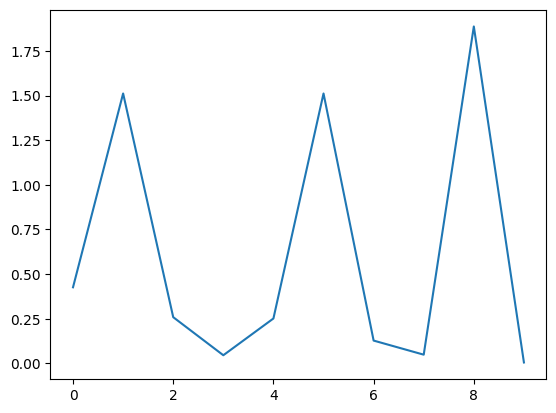

In [ ]:

quis = []
for i in range(10):
  rand = titanic.Sex.sample(n = len(titanic.Sex), ignore_index = True)
  titanic.Sex = rand
  quis.append(qui(pd.crosstab(titanic.Survived, titanic.Sex)))

sns.lineplot(quis)